# Tema 12 — Clasificación de imágenes con CNN y Transfer Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecamposv/nlp-vision/blob/main/semana-06/Tema-12/Tema_12.ipynb)

Puedes ejecutar este notebook localmente (VS Code / Jupyter) o en **Google Colab** dando clic en el badge de arriba.

En este notebook entrenamos una **red neuronal convolucional (CNN)** desde cero sobre el dataset **CIFAR-10**, y luego comparamos su desempeño con **transfer learning** y **fine-tuning** usando el modelo preentrenado **EfficientNetB0**.

> 💡 Se recomienda ejecutar en Colab con **GPU** activada (Entorno de ejecución → Cambiar tipo de entorno → GPU) para acelerar el entrenamiento.

**CNN básica entrenada desde cero**

### ¿Qué hace este código?

Entrena una **CNN desde cero** para clasificar las 10 categorías de **CIFAR-10**:

1. **Carga del dataset** CIFAR-10 (60 000 imágenes de 32×32 px) con `tf.keras.datasets`.
2. **Normalización**: los píxeles se escalan de 0–255 a un rango 0–1 para ayudar al entrenamiento.
3. **Arquitectura**: tres bloques **`Conv2D` + `MaxPooling2D`** que extraen características, seguidos de capas densas. El **`Dropout(0.3)`** reduce el sobreajuste y la capa final **`softmax`** entrega la probabilidad de cada una de las 10 clases.
4. **Compilación** con el optimizador **Adam** y la pérdida `sparse_categorical_crossentropy` (etiquetas como enteros).
5. **Entrenamiento** durante 15 épocas reservando un 20 % para validación, y **evaluación** final sobre el conjunto de prueba.

> ⏱️ Este entrenamiento puede tardar varios minutos; con GPU es mucho más rápido.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Cargar dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 2. Normalizar imágenes
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3. Nombres de las clases
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'venado',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# 4. Definir CNN básica
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# 5. Compilar modelo
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# 6. Entrenar
history_cnn = cnn_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

# 7. Evaluar
test_loss, test_acc = cnn_model.evaluate(x_test, y_test)
print("Accuracy CNN básica:", test_acc)

Matplotlib is building the font cache; this may take a moment.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3431s 20us/step


/Users/ecamposv/anaconda3/envs/tema12/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-19 19:32:05.502515: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-06-19 19:32:05.502701: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-19 19:32:05.503110: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-19 19:32:05.503298: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-19 19:32:05.503694: I tensorflow/core/common_runtime/pluggable_device/pluggable_d

Epoch 1/15


2026-06-19 19:32:08.076956: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.3867 - loss: 1.6544 - val_accuracy: 0.5183 - val_loss: 1.3569
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5371 - loss: 1.2976 - val_accuracy: 0.5996 - val_loss: 1.1328
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5954 - loss: 1.1514 - val_accuracy: 0.6357 - val_loss: 1.0480
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6293 - loss: 1.0682 - val_accuracy: 0.6495 - val_loss: 1.0093
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6500 - loss: 1.0162 - val_accuracy: 0.6490 - val_loss: 1.0139
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.6637 - loss: 0.9774 - val_accuracy: 0.6843 - val_loss: 0.9163
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.6728 - loss: 0.9585 - val_accuracy: 0.6835 - val_loss: 0.9373
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.6798 - loss: 0.9448 - val_accurac

Transfer learning con EfficientNetB0

### ¿Qué hace este código?

Aplica **transfer learning** reutilizando un modelo ya entrenado en millones de imágenes (**ImageNet**):

1. **Pipeline `tf.data` optimizado**: en vez de redimensionar las imágenes de golpe a 224×224 (lo que consume mucha memoria y provoca un error **OOM**), se crean datasets que **redimensionan por lotes**. Además:
   - Se usa un **subconjunto** (`N_TRAIN`, `N_TEST`) porque con transfer learning bastan pocas imágenes para buena precisión → entrena mucho más rápido.
   - Se **cachea en disco temporal** (`/tmp`, válido en Colab y en local) para que el resize se calcule **una sola vez** y no en cada época.
   - Se usa `BATCH = 64` para aprovechar mejor la GPU.
2. Carga el modelo base **EfficientNetB0** con `include_top=False` (sin la capa de clasificación original) y pesos de **ImageNet**.
3. **Congela** el modelo base (`trainable = False`): se usa solo como **extractor de características**, sin reentrenar sus pesos.
4. Añade una cabeza nueva: `GlobalAveragePooling2D` + `Dropout` + una capa `Dense` **softmax** con 10 salidas.
5. **Compila, entrena** (solo la cabeza) con **`EarlyStopping`** (corta si la validación deja de mejorar) y **evalúa** con `test_ds`.

> ⚡ La **primera época** es más lenta porque construye la caché; las siguientes son mucho más rápidas.
> 💡 Para usar **todas** las imágenes, sube `N_TRAIN`/`N_TEST` (más precisión, más tiempo). Si te falta memoria, baja `BATCH`.

In [ ]:
# 1. Pipeline de datos: redimensiona a 224x224 POR LOTES (evita el error OOM)
# En lugar de redimensionar las 50 000 imágenes de golpe (~30 GB), usamos
# tf.data para hacerlo sobre la marcha, lote por lote.
import os
import tempfile

IMG_SIZE = (224, 224)
BATCH = 64                 # batch más grande = mejor uso de la GPU
AUTOTUNE = tf.data.AUTOTUNE

# Subconjunto: con transfer learning bastan pocas imágenes para buena precisión.
# Reduce el tiempo de entrenamiento y el tamaño de la caché (funciona bien en Colab).
N_TRAIN = 15000   # de 50 000 -> menos tiempo, menos disco
N_TEST = 3000     # de 10 000

# Caché en disco temporal (/tmp en Colab y en local): el resize 32->224
# se calcula UNA sola vez y se reutiliza en cada época.
CACHE_DIR = os.path.join(tempfile.gettempdir(), "tf_cache_tema12")
os.makedirs(CACHE_DIR, exist_ok=True)

# Tomamos el subconjunto
x_sub, y_sub = x_train[:N_TRAIN], y_train[:N_TRAIN]
x_test_sub, y_test_sub = x_test[:N_TEST], y_test[:N_TEST]

# Separación manual train/validación (20%), ya que tf.data no usa validation_split
val_count = int(len(x_sub) * 0.2)
x_tr, y_tr = x_sub[:-val_count], y_sub[:-val_count]
x_val, y_val = x_sub[-val_count:], y_sub[-val_count:]

def make_ds(x, y, cache_name, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    # EfficientNet trae su propia normalización interna y espera píxeles en [0, 255];
    # como x_train ya está en [0, 1], lo reescalamos de vuelta multiplicando por 255.
    ds = ds.map(lambda img, lbl: (tf.image.resize(img, IMG_SIZE) * 255.0, lbl),
                num_parallel_calls=AUTOTUNE)
    # cache a disco temporal: el resize se calcula una sola vez y se reutiliza.
    ds = ds.cache(os.path.join(CACHE_DIR, cache_name))
    if training:
        ds = ds.shuffle(2000)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_ds(x_tr, y_tr, "train", training=True)
val_ds = make_ds(x_val, y_val, "val")
test_ds = make_ds(x_test_sub, y_test_sub, "test")

# 2. Modelo base preentrenado
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# 3. Congelar extractor de características
base_model.trainable = False

# 4. Construir modelo final
tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# 5. Compilar
tl_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# EarlyStopping: detiene el entrenamiento si la validación deja de mejorar
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True
)

# 6. Entrenar
history_tl = tl_model.fit(
    train_ds,
    epochs=8,
    validation_data=val_ds,
    callbacks=[early_stop]
)

# 7. Evaluar
test_loss_tl, test_acc_tl = tl_model.evaluate(test_ds)
print("Accuracy Transfer Learning:", test_acc_tl)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 274s 210ms/step - accuracy: 0.0991 - loss: 2.3347 - val_accuracy: 0.1016 - val_loss: 2.3411
Epoch 2/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 279s 223ms/step - accuracy: 0.1003 - loss: 2.3325 - val_accuracy: 0.1003 - val_loss: 2.3302
Epoch 3/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 276s 221ms/step - accuracy: 0.1021 - loss: 2.3321 - val_accuracy: 0.1016 - val_loss: 2.3098
Epoch 4/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 279s 223ms/step - accuracy: 0.1009 - loss: 2.3318 - val_accuracy: 0.1025 - val_loss: 2.3363
Epoch 5/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 279s 223ms/step - accuracy: 0.0994 - loss: 2.3324 - val_accuracy: 0.1014 - val_loss: 2.3087
Epoch 6/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 277s 222ms/step - accuracy: 0.1002 - loss: 2.3319 - val_accuracy: 0.1003 - val_loss: 2.3083
Epoch 7/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 274s 220ms/step - accuracy: 0.1028 - loss: 2.3313 - val_accuracy: 0.1003 - val_loss: 2.3185
Epoch 8/8
1250/125

**Fine-tuning parcial**

### ¿Qué hace este código?

Mejora el modelo con **fine-tuning**: ajusta las últimas capas del modelo preentrenado a nuestro problema:

1. **Descongela** el modelo base (`trainable = True`) pero vuelve a congelar todas las capas **excepto las últimas 20**, que son las que se reentrenarán.
2. **Recompila** con un **learning rate muy pequeño** (`1e-5`) para no destruir lo que el modelo ya aprendió.
3. **Reentrena** unas pocas épocas y vuelve a **evaluar**.

> 💡 El fine-tuning suele dar el último empujón de precisión, pero usar un learning rate alto aquí puede empeorar el modelo.

In [ ]:
# Descongelar las últimas capas del modelo base
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompilar con learning rate pequeño
tl_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# Reentrenar (reutiliza los datasets cacheados; EarlyStopping corta si no mejora)
history_ft = tl_model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds,
    callbacks=[early_stop]
)

# Evaluación final
test_loss_ft, test_acc_ft = tl_model.evaluate(test_ds)
print("Accuracy Fine-Tuning:", test_acc_ft)


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 361s 279ms/step - accuracy: 0.1021 - loss: 2.3184 - val_accuracy: 0.0998 - val_loss: 2.3036
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 350s 280ms/step - accuracy: 0.1029 - loss: 2.3126 - val_accuracy: 0.0983 - val_loss: 2.3016
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 329s 263ms/step - accuracy: 0.1056 - loss: 2.3090 - val_accuracy: 0.1116 - val_loss: 2.3017
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 333s 266ms/step - accuracy: 0.1117 - loss: 2.3047 - val_accuracy: 0.1050 - val_loss: 2.2968
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 334s 267ms/step - accuracy: 0.1122 - loss: 2.3037 - val_accuracy: 0.1021 - val_loss: 2.2969
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 193ms/step - accuracy: 0.0991 - loss: 2.2967
Accuracy Fine-Tuning: 0.09910000115633011


**Curvas de entrenamiento**

### ¿Qué hace este código?

Define una función para **graficar las curvas de entrenamiento** y la usa para comparar modelos:

1. `plot_history` recibe el historial devuelto por `model.fit` y dibuja dos gráficas: **accuracy** y **loss**.
2. En cada gráfica se comparan las curvas de **entrenamiento** vs **validación** a lo largo de las épocas.
3. Se grafican los resultados de la **CNN básica** y del **Transfer Learning**.

> 🔍 Si la curva de entrenamiento sube pero la de validación se estanca o baja, es señal de **sobreajuste**.

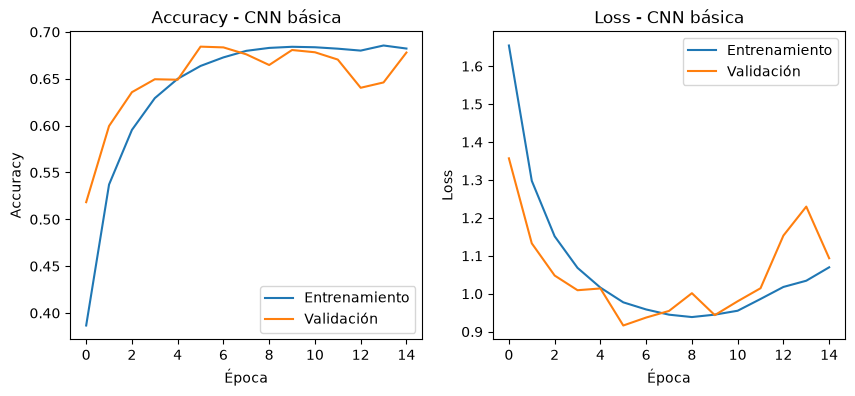

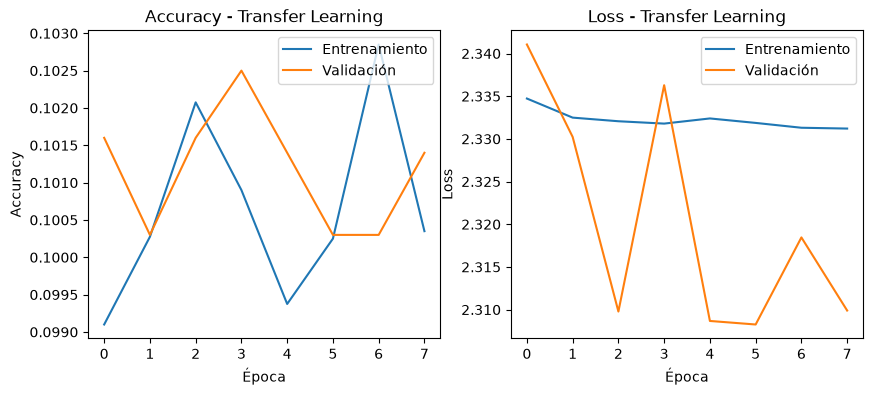

In [6]:
def plot_history(history, title):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title(f'Accuracy - {title}')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title(f'Loss - {title}')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history_cnn, "CNN básica")
plot_history(history_tl, "Transfer Learning")

**Matriz de confusión y reporte de clasificación**

### ¿Qué hace este código?

Evalúa en detalle el modelo final con una **matriz de confusión** y un **reporte de clasificación**:

1. Genera predicciones sobre el conjunto de prueba y convierte las probabilidades en clases con `np.argmax`.
2. **Matriz de confusión** (`confusion_matrix`): muestra, para cada clase real, cuántas imágenes se predijeron en cada categoría. Se visualiza como un mapa de calor con `seaborn`.
3. **`classification_report`**: imprime **precisión, recall y F1-score** por clase, útil para detectar qué categorías confunde más el modelo.

> 🔍 Los valores fuera de la diagonal de la matriz indican los errores (por ejemplo, confundir *gato* con *perro*).

313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 186ms/step


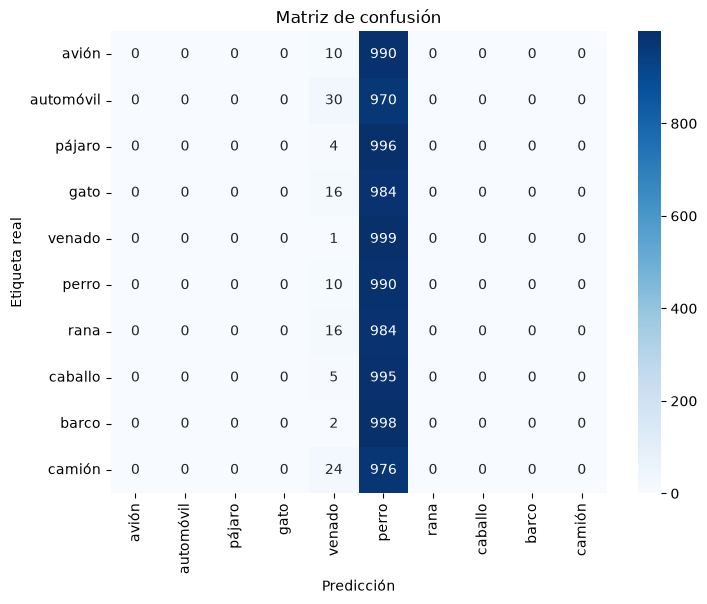

              precision    recall  f1-score   support

       avión       0.00      0.00      0.00      1000
   automóvil       0.00      0.00      0.00      1000
      pájaro       0.00      0.00      0.00      1000
        gato       0.00      0.00      0.00      1000
      venado       0.01      0.00      0.00      1000
       perro       0.10      0.99      0.18      1000
        rana       0.00      0.00      0.00      1000
     caballo       0.00      0.00      0.00      1000
       barco       0.00      0.00      0.00      1000
      camión       0.00      0.00      0.00      1000

    accuracy                           0.10     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.10      0.02     10000



/Users/ecamposv/anaconda3/envs/tema12/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ecamposv/anaconda3/envs/tema12/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ecamposv/anaconda3/envs/tema12/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [ ]:
# Predicciones con el modelo final (usa el dataset de prueba por lotes)
y_pred = tl_model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

# Usamos el mismo subconjunto de prueba que test_ds
y_true = y_test_sub.flatten()

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión")
plt.show()

# Reporte de clasificación
print(classification_report(y_true, y_pred_classes, target_names=class_names))
